In [1]:
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()

## A Minorizing Function

One of the positive qualities of the EM algorithm is that it is very stable. Unlike Newton's algorithm, where each iteration may or may not be closer to the optimal value, each iteratation of the EM algorithm is designed to increase the observed log-likelihood. This is the *ascent property of the EM algorithm*, which we will show later. This stability, though, comes at a price—the EM algorithm's convergence rate is linear (while Newton's algorithm is quadratic). This can make running the EM algorithm painful at times, particularly when one has to compute standard errors via a resampling approach like the bootstrap.

The EM algorithm is a *minorization* approach. Instead of directly maximizing the log-likelihood, which is difficult to evaluate, the algorithm constructs a minorizing function and optimizes that function instead. What is a minorizing function? Following Chapter 7 of Jan de Leeuw's [*Block Relaxation Algorithms in Statistics*](http://gifi.stat.ucla.edu/bras/_book/majorization-methods.html#introduction-1) a function $g$ *minorizes* $f$ over $\mathcal{X}$ at $y$ if

1. $g(x) \leq f(x)$ for all $x\in\mathcal{X}$
2. $g(y) = f(y)$

In the description of the EM algorithm above, $Q(\theta\mid\theta_0)$ is the minorizing function. The benefits of this approach are

1. The $Q(\theta\mid\theta_0)$ is a much nicer function that is easy to optimize
2. Because the $Q(\theta\mid\theta_0)$ minorizes $\ell(\theta\mid y)$, maximizing it is guaranteed to increase (or at least not decrease) $\ell(\theta\mid y)$. This is because if $\theta_n$ is our current estimate of $\theta$ and $Q(\theta\mid\theta_n)$ minorizes $\ell(\theta\mid y)$ at $\theta_n$, then we have

$$\ell(\theta_{n+1}\mid y) \geq Q(\theta_{n+1}\mid\theta_n) \geq Q(\theta_n\mid\theta_n) = \ell(\theta_n\mid y).$$

Let's take a look at how this minorization process works. We can begin with the observed log-likelihood

$$\log f(y\mid\theta) = \log\int g(y,z\mid\theta)\,dz.$$

Using the time-honored strategy of adding and subtracting, we can show that if $\theta_0$ is our current estimate of $\theta$,

$$\begin{eqnarray*}
\log f(y\mid\theta)-\log f(y\mid\theta_0) & = & \log\int g(y,z\mid\theta)\,dz - \log\int g(y,z\mid\theta_0)\,dz\\
& = & \log\frac{\int g(y,z\mid\theta)\,dz}{\int g(y,z\mid\theta_0)\,dz}\\
& = & \log\frac{\int g(y,z\mid\theta_0)\frac{g(y,z\mid\theta)}{g(y,z\mid\theta_0)}\,dz}{\int g(y,z\mid\theta_0)\,dz}
\end{eqnarray*}$$

Now, because we have defined

$$h(z\mid y,\theta) = \frac{g(y,z\mid\theta)}{f(y\mid\theta)} = \frac{g(y,z\mid\theta)}{\int g(y,z\mid\theta)\,dz}$$

we can write

$$\begin{eqnarray*}
\log f(y\mid\theta)-\log f(y\mid\theta_0) & = & \log\int h(z\mid y, \theta_0)\frac{g(y,z\mid\theta)}{g(y,z\mid\theta_0)}\,dz\\
& = & \log \mathbb{E}\left[\left.\frac{g(y,z\mid\theta)}{g(y,z\mid\theta_0)}\right| y, \theta_0\right]
\end{eqnarray*}$$

Because the $\log$ function is concave, [Jensen's inequality](https://en.wikipedia.org/wiki/Jensen%27s_inequality) tells us that

$$\log \mathbb{E}\left[\left.\frac{g(y,z\mid\theta)}{g(y,z\mid\theta_0)}\right| y, \theta_0\right] \geq \mathbb{E}\left[\log\left.\frac{g(y,z\mid\theta)}{g(y,z\mid\theta_0)}\right| y, \theta_0\right].$$

Taking this, we can then write

$$\log f(y\mid\theta)-\log f(y\mid\theta_0) \geq \mathbb{E}\left[\log\left.\frac{g(y,z\mid\theta)}{g(y,z\mid\theta_0)}\right| y, \theta_0\right],$$

which then gives us

$$\begin{eqnarray*}
\log f(y\mid\theta) & \geq & \log f(y\mid\theta_0) + \mathbb{E}[\log g(y,z\mid\theta)\mid y, \theta_0] - \mathbb{E}[\log g(y,z\mid\theta_0)\mid y, \theta_0]\\
& = & \log f(y\mid\theta_0) + Q(\theta\mid\theta_0) - Q(\theta_0\mid\theta_0)
\end{eqnarray*}$$

The right-hand side of the above equation, the middle part of which is a function of $\theta$, is our minorizing function. We can see that for $\theta=\theta_0$ we have that the minorizing function is equal to $\log f(y\mid\theta_0)$.

### Example: Minorization in a Two-Part Mixture Model

We will revisit the two-part Normal mixture model from before. Suppose we have data $y_1,\dots,y_n$ that are sampled independently from a two-part mixture of Normals model with density

$$f(y\mid\lambda) = \lambda\varphi(y\mid\mu_1,\sigma_1^2) + (1-\lambda)\varphi(y\mid\mu_2,\sigma_2^2).$$

We can simulate some data from this model.

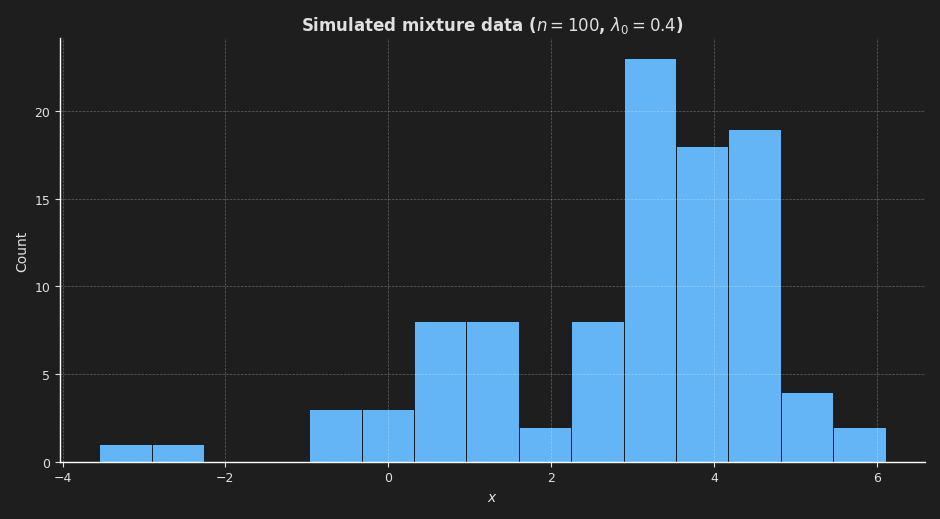

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, stats
mu1 = 1
s1 = 2
mu2 = 4
s2 = 1
lambda0 = 0.4
n = 100
rng = np.random.default_rng(20170912)
z = rng.binomial(1, lambda0, size=n)     # 'Missing' data
x = rng.normal(mu1 * z + mu2 * (1-z), s1 * z + (1-z) * s2)
fig, ax = plt.subplots()
ax.hist(x, bins=15, color=C['blue'], edgecolor='black', linewidth=0.5)
ax.set_xlabel('$x$')
ax.set_ylabel('Count')
ax.set_title('Simulated mixture data ($n=100$, $\\lambda_0=0.4$)')
plt.tight_layout()


For the purposes of this example, let's assume that $\mu_1, \mu_2, \sigma_1^2$, and $\sigma_2^2$ are known. The only unknown parameter is $\lambda$, the mixing proportion. The observed data log-likelihood is

$$\log f(y_1,\ldots,y_n\mid\lambda) = \log\sum_{i=1}^n \left[\lambda\varphi(y_i\mid\mu_1,\sigma_1^2) + (1-\lambda)\varphi(y_i\mid\mu_2,\sigma_2^2)\right].$$

We can plot the observed data log-likelihood in this case with the simulated data above. First, we can write a function encoding the mixture density as a function of the data and $\lambda$.

In [3]:
def f(x, lam, mu1, mu2, s1, s2):
    """PDF of mixture of two Gaussians"""
    return lam * stats.norm.pdf(x, mu1, s1) + (1 - lam) * stats.norm.pdf(x, mu2, s2)

def loglike(lam):
    """Log-likelihood of lambda given observed data x"""
    return np.sum(np.log(f(x, lam, mu1, mu2, s1, s2)))

Note that the true value is $\lambda = 0.4$. We can compute the maximum likelihood estimate in this simple case with

In [4]:
op = optimize.minimize_scalar(lambda x: -loglike(x), bounds=(0.1, 0.9), method="bounded")
op.x

np.float64(0.3331367440200367)

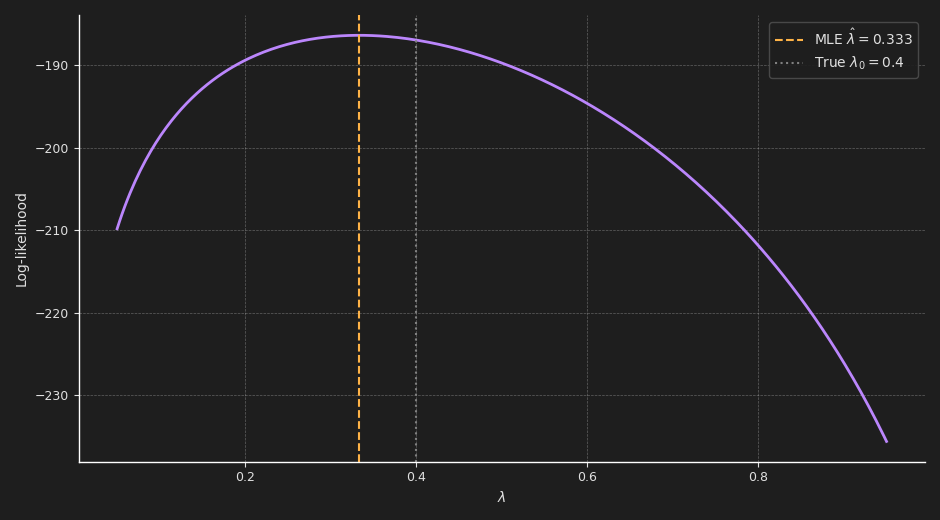

In [5]:
lam_grid = np.linspace(0.05, 0.95, 300)
ll_vals = np.array([loglike(l) for l in lam_grid])
mle = op.x
fig, ax = plt.subplots()
ax.plot(lam_grid, ll_vals, lw=2)
ax.axvline(mle, linestyle='--', color=C['orange'], lw=1.5, label=f'MLE $\\hat{{\\lambda}}={mle:.3f}$')
ax.axvline(lambda0, linestyle=':', color='gray', lw=1.5, label=f'True $\\lambda_0={lambda0}$')
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('Log-likelihood')
ax.legend(fontsize=10)
plt.tight_layout()



In this case it would appear that the maximum likelihood estimate exhibits some bias, but we won't worry about that right now.

We can illustrate how the minorizing function works by starting with an initial value of $\lambda_0 = 0.8$.

Now we can plot the minorizing function along with the observed log-likelihood.

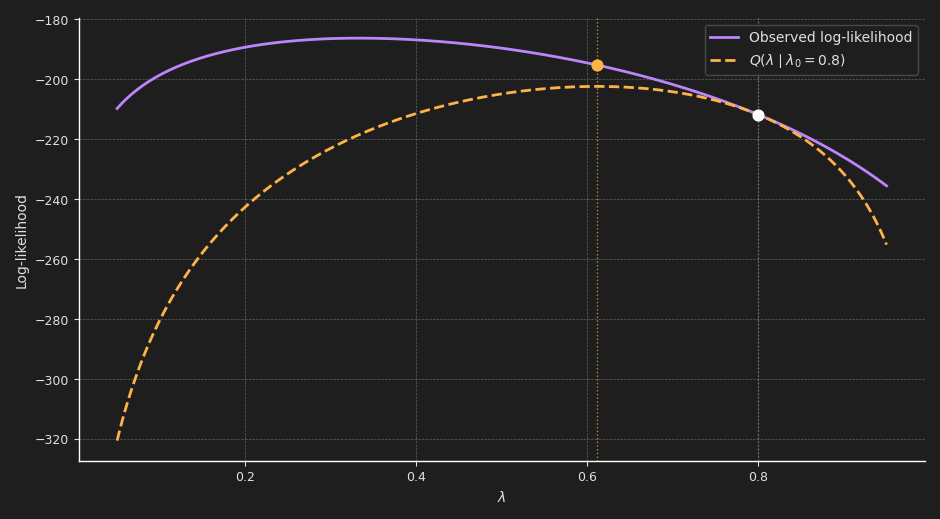

In [6]:
def make_pi(lam, y):
    """Posterior prob. that each obs came from component 1 (E-step)"""
    num = lam * stats.norm.pdf(y, mu1, s1)
    denom = num + (1 - lam) * stats.norm.pdf(y, mu2, s2)
    return num / denom

def q_func(lam_grid, lambda0_val):
    """Q function (minorizing function) shifted to touch log-likelihood at lambda0_val"""
    pi_hat = make_pi(lambda0_val, x)
    pi_bar = np.mean(pi_hat)
    q_vals = n * pi_bar * np.log(lam_grid) + n * (1 - pi_bar) * np.log(1 - lam_grid)
    # Shift so Q touches log-likelihood at lambda0_val
    ll0 = loglike(lambda0_val)
    q0 = n * pi_bar * np.log(lambda0_val) + n * (1 - pi_bar) * np.log(1 - lambda0_val)
    return q_vals + (ll0 - q0), np.mean(pi_hat)  # pi_bar gives next lambda

lam_grid = np.linspace(0.05, 0.95, 300)
ll_vals = np.array([loglike(l) for l in lam_grid])

lam0 = 0.8
q_vals1, lam1 = q_func(lam_grid, lam0)

fig, ax = plt.subplots()
ax.plot(lam_grid, ll_vals, lw=2, label='Observed log-likelihood')
ax.plot(lam_grid, q_vals1, lw=2, linestyle='--', color=C['orange'], label=f'$Q(\\lambda\\mid\\lambda_0={lam0})$')
ax.axvline(lam0, linestyle=':', color='gray', lw=1, alpha=0.7)
ax.axvline(lam1, linestyle=':', color=C['orange'], lw=1, alpha=0.7)
ax.scatter([lam0], [loglike(lam0)], color='white', zorder=5, s=60)
ax.scatter([lam1], [loglike(lam1)], color=C['orange'], zorder=5, s=60)
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('Log-likelihood')
ax.legend(fontsize=10)
plt.tight_layout()


Maximizing the minorizing function gives us the next estimate of $\lambda$ in the EM algorithm. It's clear from the picture that maximizing the minorizing function will increase the observed log-likelihood.

In the figure above, the second minorizing function is constructed using $\lambda_1$ and maximized to get $\lambda_2$. This process of constructing the minorizing function and maximizing can be repeated until convergence. This is the EM algorithm at work!

### Constrained Minimization With an Adaptive Barrier

The flip side of minorization is majorization, which is used in minimization problems. We can implement a constrained minimization procedure by creating a surrogate function that majorizes the target function and satisfies the constraints. Specifically, the goal is to minimize a function $f(\theta)$ subject to a set of constraints of the form $g_i(\theta) \geq 0$ where

$$g_i(\theta) = u_i'\theta - c_i$$

and where $u_i$ is a vector of the same length as $\theta$, $c_i$ is a constant, and $i = 1,\ldots,\ell$. These constraints are *linear* constraints on the parameters. Given the constraints and $\theta_n$, the estimate of $\theta$ at iteration $n$, we can construct the surrogate function,

$$R(\theta\mid\theta_n) = f(\theta) - \lambda\sum_{i=1}^\ell g_i(\theta_n)\log g_i(\theta) - u_i'\theta$$

with $\lambda > 0$.